In [2]:

import pandas as pd         
import numpy as np           
import matplotlib.pyplot as plt  
import seaborn as sns            
from sklearn.preprocessing import StandardScaler  
from sklearn.decomposition import PCA          
from sklearn.cluster import (
    KMeans,                  
    MiniBatchKMeans,        
    DBSCAN,                  
    AgglomerativeClustering, 
    Birch                   
)
from sklearn.mixture import GaussianMixture     
from sklearn.metrics import (
    silhouette_score,         
    davies_bouldin_score,     
    calinski_harabasz_score   
)
import warnings
import time
warnings.filterwarnings('ignore')   
np.random.seed(42)                 

print('✅ All libraries imported successfully!')

✅ All libraries imported successfully!


# Load the Dataset

In [2]:
df = pd.read_csv('single_genre_artists.csv')

print(f'Dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns')
print()

df.head(3)

Dataset shape: 95,837 rows × 23 columns



,id_songs,name_song,popularity_songs,duration_ms,explicit,id_artists,release_date,danceability,energy,key,...,acousticness,instrumentalness,liveness,valence,tempo,time_signature,followers,genres,name_artists,popularity_artists
0,0IA0Hju8CAgYfV1hwhidBH,La Java,0,161427,0,4AxgXfD7ISvJSTObqm4aIE,1922,0.563,0.184,4,...,0.993,0.000016,0.325,0.654,133.088,3,5078.0,['vintage chanson'],Mistinguett,22
1,1b8HZQCqcqwbzlA1jRTp6E,En Douce,0,223440,0,4AxgXfD7ISvJSTObqm4aIE,1922,0.427,0.180,10,...,0.989,0.000000,0.128,0.431,78.459,3,5078.0,['vintage chanson'],Mistinguett,22
2,5d5gQxHwYovxR5pqETOIAa,J'en Ai Marre,0,208267,0,4AxgXfD7ISvJSTObqm4aIE,1922,0.511,0.206,0,...,0.995,0.000000,0.418,0.481,70.443,4,5078.0,['vintage chanson'],Mistinguett,22


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 95837 entries, 0 to 95836
Data columns (total 23 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id_songs            95837 non-null  object 
 1   name_song           95837 non-null  object 
 2   popularity_songs    95837 non-null  int64  
 3   duration_ms         95837 non-null  int64  
 4   explicit            95837 non-null  int64  
 5   id_artists          95837 non-null  object 
 6   release_date        95837 non-null  object 
 7   danceability        95837 non-null  float64
 8   energy              95837 non-null  float64
 9   key                 95837 non-null  int64  
 10  loudness            95837 non-null  float64
 11  mode                95837 non-null  int64  
 12  speechiness         95837 non-null  float64
 13  acousticness        95837 non-null  float64
 14  instrumentalness    95837 non-null  float64
 15  liveness            95837 non-null  float64
 16  vale

In [4]:
df.describe().round(3)

,popularity_songs,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,followers,popularity_artists
count,95837.000,95837.000,95837.00,95837.000,95837.000,95837.000,95837.000,95837.000,95837.000,95837.000,95837.000,95837.000,95837.000,95837.000,95837.000,9.583700e+04,95837.000
mean,26.066,208732.032,0.03,0.587,0.541,5.197,-10.158,0.648,0.169,0.459,0.082,0.225,0.574,117.540,3.851,1.979919e+05,42.819
std,16.254,117752.556,0.17,0.155,0.236,3.535,4.749,0.478,0.275,0.330,0.232,0.186,0.248,30.190,0.544,7.807520e+05,20.898
min,0.000,6373.000,0.00,0.000,0.000,0.000,-50.174,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000000e+00,0.000
25%,13.000,157333.000,0.00,0.488,0.365,2.000,-12.723,0.000,0.034,0.133,0.000,0.100,0.378,94.829,4.000,2.563000e+03,28.000
50%,26.000,204000.000,0.00,0.605,0.542,5.000,-9.397,1.000,0.046,0.453,0.000,0.149,0.589,116.595,4.000,1.595600e+04,40.000
75%,37.000,250267.000,0.00,0.700,0.727,8.000,-6.692,1.000,0.103,0.759,0.001,0.302,0.780,135.975,4.000,8.495100e+04,56.000
max,98.000,4800118.000,1.00,0.991,1.000,11.000,5.376,1.000,0.968,0.996,1.000,0.997,1.000,239.906,5.000,2.802643e+07,95.000



#  Exploratory Data Analysis (EDA)


In [5]:

audio_cols = [
    'danceability',     
    'energy',           
    'key',             
    'loudness',        
    'mode',             
    'speechiness',     
    'acousticness',    
    'instrumentalness', 
    'liveness',         
    'valence',          
    'tempo',
    'time_signature',   
    'popularity_songs', 
    'explicit',       
    'duration_ms',      
]

print(f'We will use {len(audio_cols)} features for clustering:')
for col in audio_cols:
    print(f'  • {col}')

We will use 15 features for clustering:
  • danceability
  • energy
  • key
  • loudness
  • mode
  • speechiness
  • acousticness
  • instrumentalness
  • liveness
  • valence
  • tempo
  • time_signature
  • popularity_songs
  • explicit
  • duration_ms


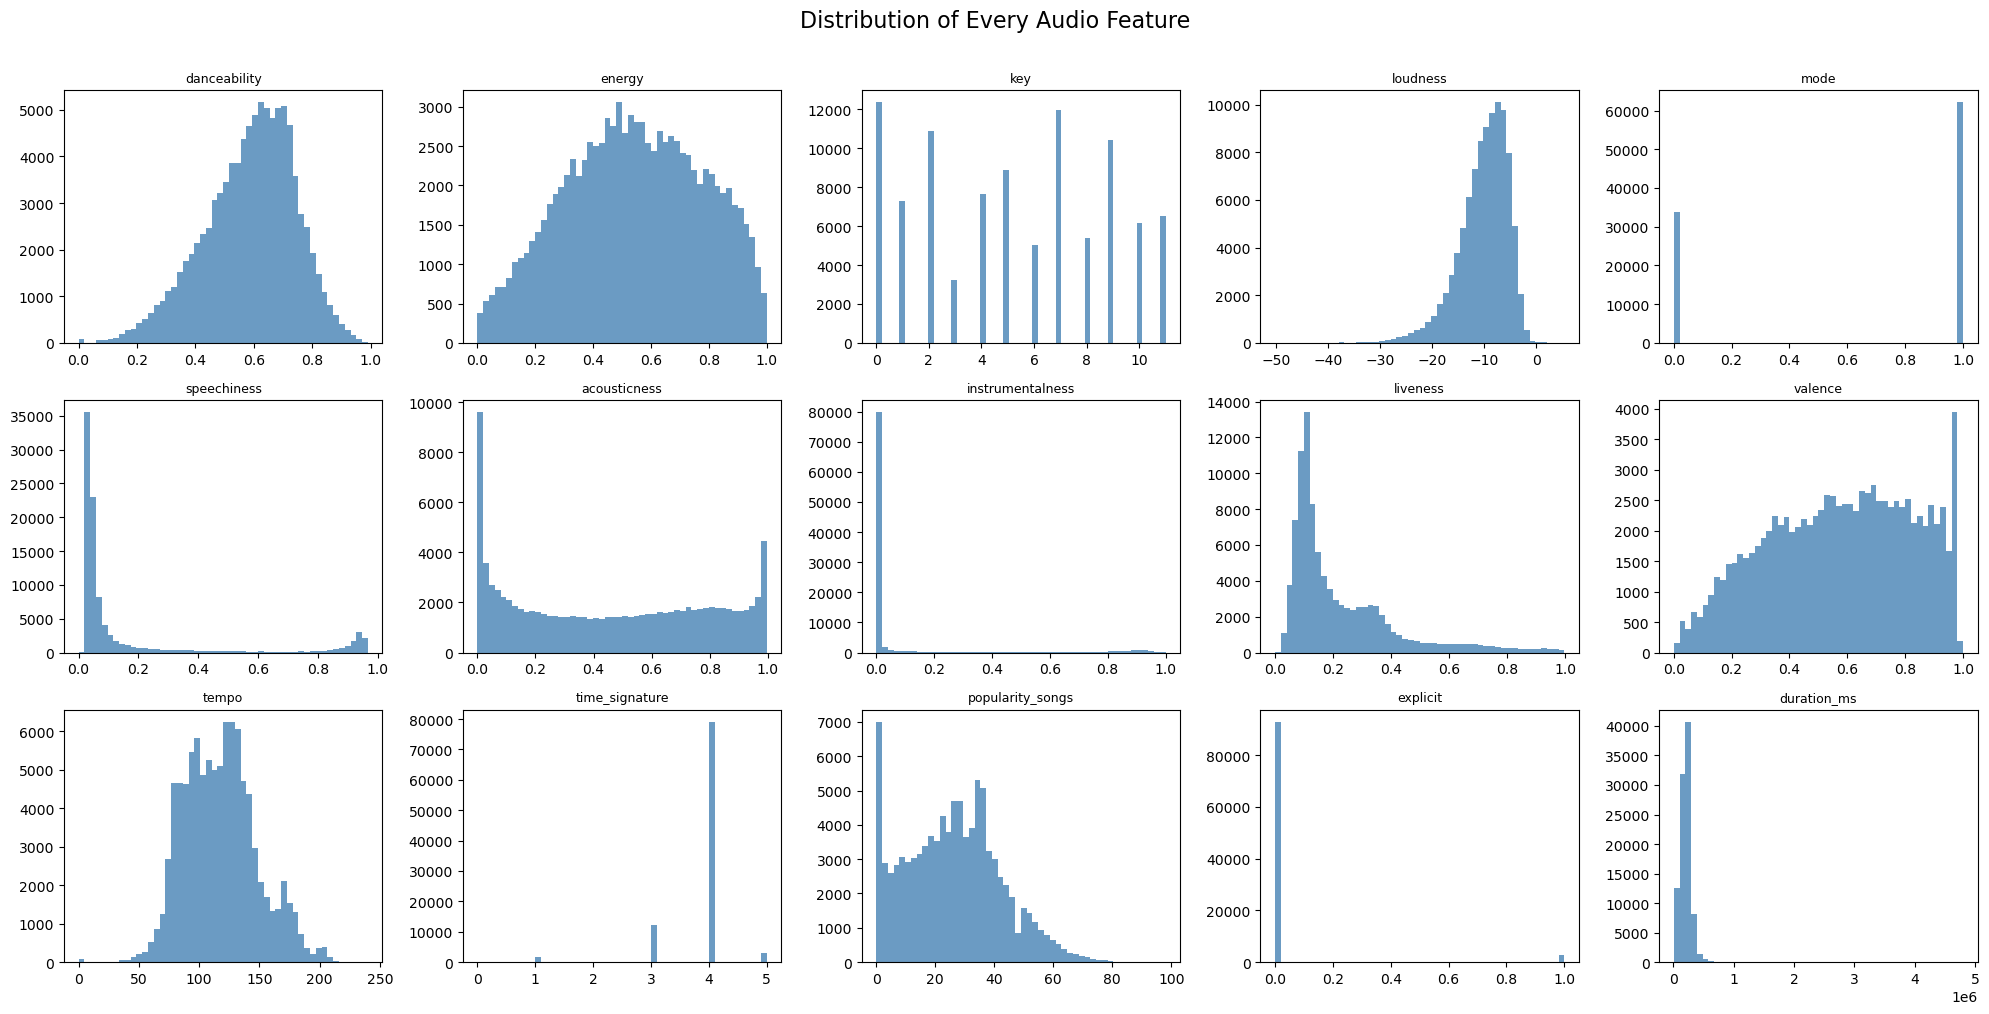

In [6]:

fig, axes = plt.subplots(3, 5, figsize=(20, 10))
fig.suptitle('Distribution of Every Audio Feature', fontsize=16, y=1.01)

for ax, col in zip(axes.flat, audio_cols):
    ax.hist(df[col].dropna(), bins=50, color='steelblue', alpha=0.8, edgecolor='none')
    ax.set_title(col, fontsize=9)
    ax.set_xlabel('')

plt.tight_layout()
plt.show()



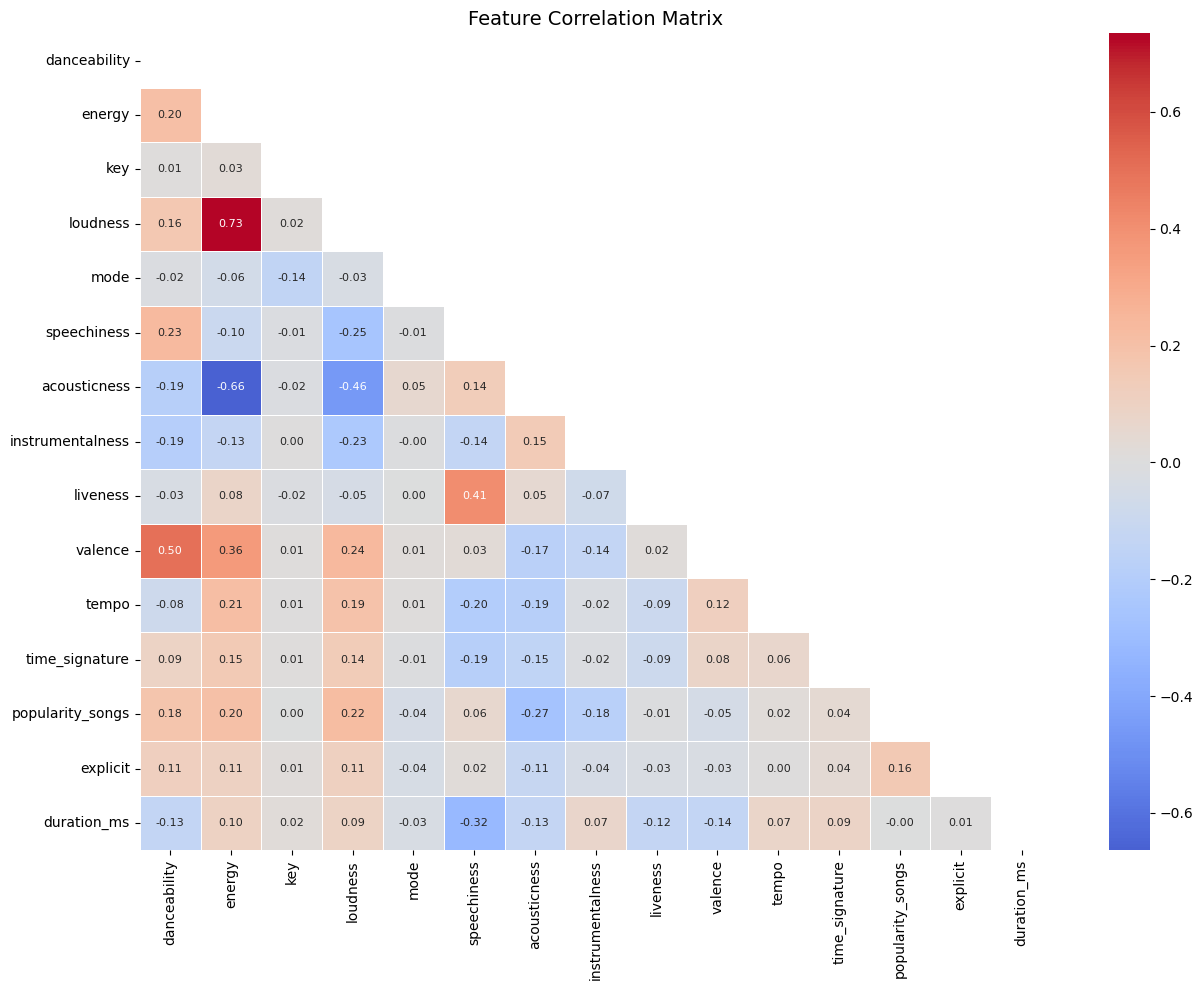

In [7]:


fig, ax = plt.subplots(figsize=(13, 10))
corr = df[audio_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))  

sns.heatmap(corr, mask=mask, cmap='coolwarm', center=0,
            annot=True, fmt='.2f', linewidths=0.5,
            annot_kws={'size': 8})
ax.set_title('Feature Correlation Matrix', fontsize=14)
plt.tight_layout()
plt.show()



In [8]:

missing = df[audio_cols].isnull().sum()
print('Missing values per feature:')
print(missing)
print()

if missing.sum() == 0:
    print('✅ No missing values — great!')
else:
    print(f'⚠️  Found {missing.sum()} missing values — we will handle them in Step 4')

Missing values per feature:
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
popularity_songs    0
explicit            0
duration_ms         0
dtype: int64

✅ No missing values — great!


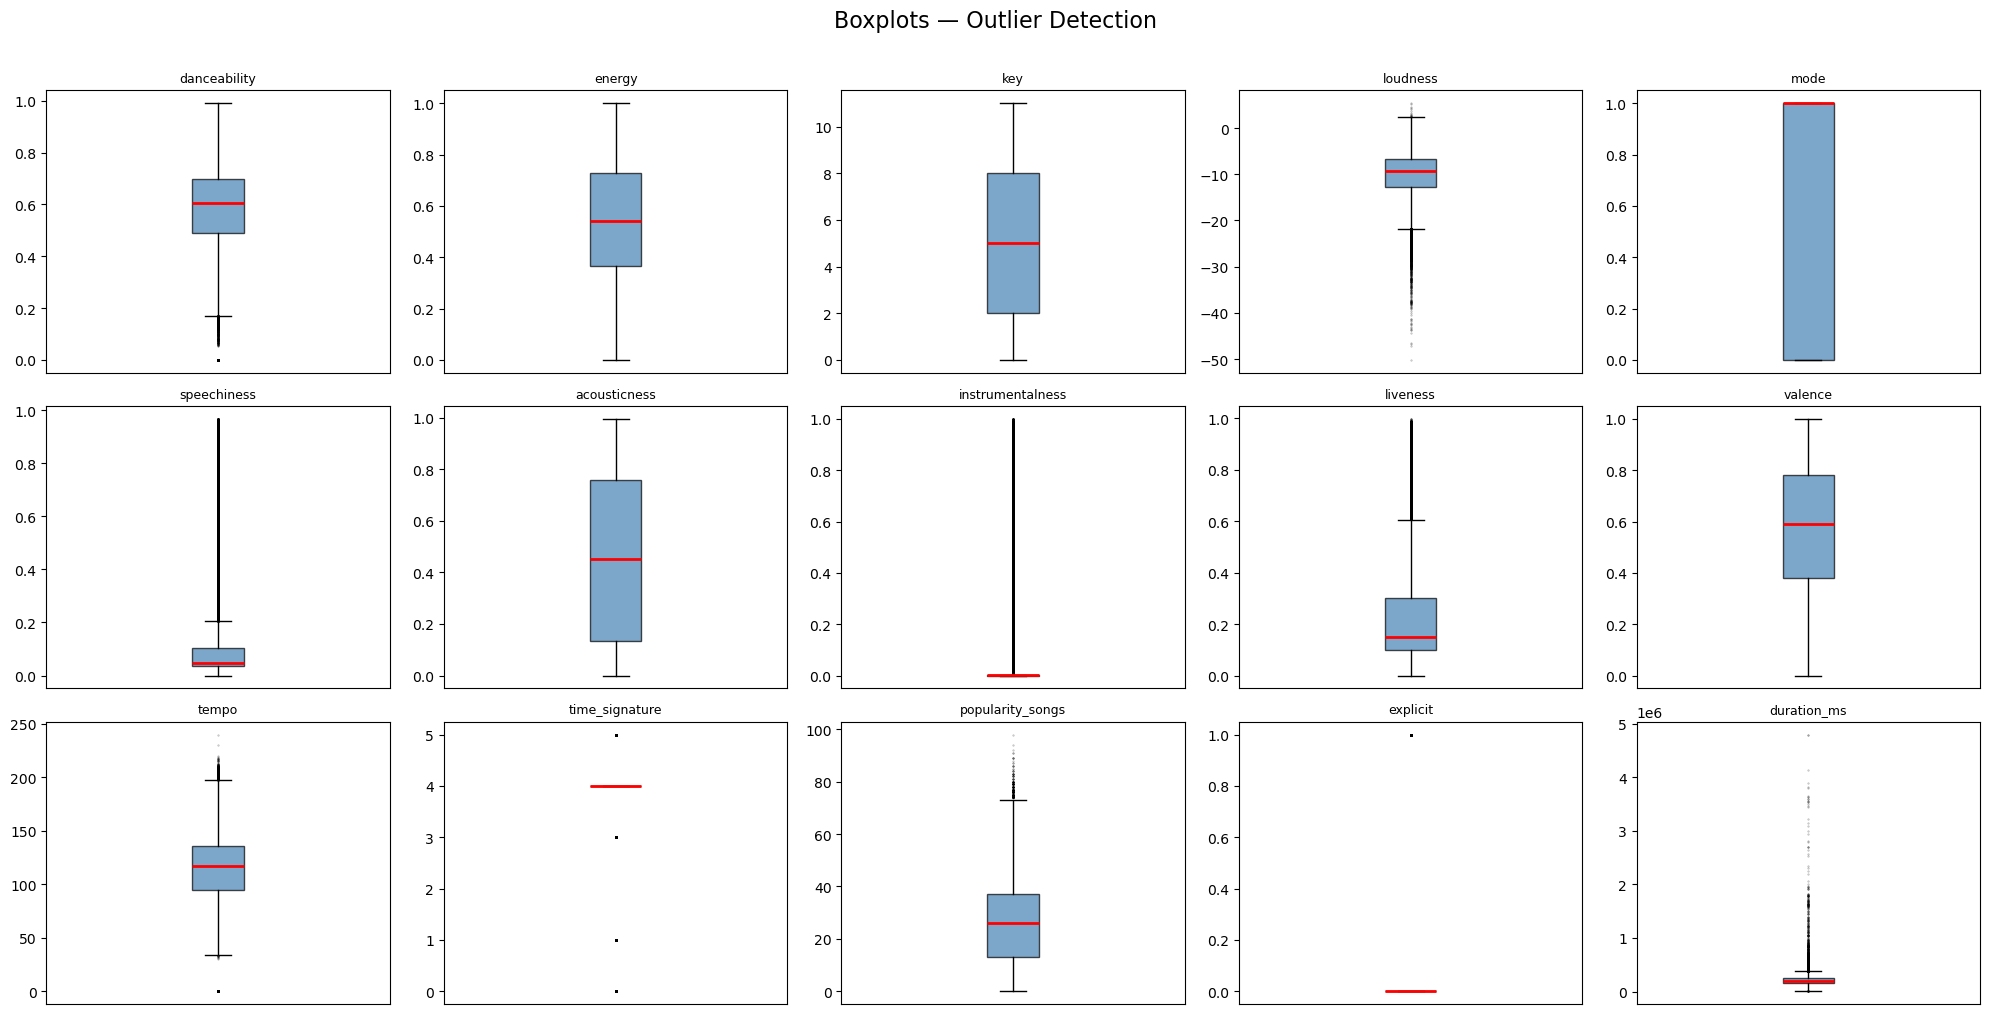

In [9]:


fig, axes = plt.subplots(3, 5, figsize=(20, 10))
fig.suptitle('Boxplots — Outlier Detection', fontsize=16, y=1.01)

for ax, col in zip(axes.flat, audio_cols):
    ax.boxplot(df[col].dropna(), vert=True, patch_artist=True,
               boxprops=dict(facecolor='steelblue', alpha=0.7),
               medianprops=dict(color='red', linewidth=2),
               flierprops=dict(marker='.', markersize=1, alpha=0.3))
    ax.set_title(col, fontsize=9)
    ax.set_xticks([])

plt.tight_layout()
plt.show()




#  Data Cleaning


In [10]:


df = df[audio_cols].copy()  

print(f'Before cleaning: {df.shape[0]:,} rows')

Before cleaning: 95,837 rows


In [11]:

skewed_cols = ['duration_ms', 'speechiness', 'instrumentalness']

for col in skewed_cols:
    q_low  = df[col].quantile(0.01)   
    q_high = df[col].quantile(0.99)  

    rows_before = len(df)
    df = df[(df[col] >= q_low) & (df[col] <= q_high)]
    rows_removed = rows_before - len(df)

    print(f'{col:25s}: kept range [{q_low:.2f} → {q_high:.2f}]  │  removed {rows_removed:,} rows')

df = df.reset_index(drop=True)  

print()
print(f'After cleaning: {df.shape[0]:,} rows  (removed {df.shape[0] - df.shape[0]:,} outlier rows)')
print('✅ Outlier removal complete')

duration_ms              : kept range [54754.56 → 496441.60]  │  removed 1,918 rows
speechiness              : kept range [0.03 → 0.95]  │  removed 1,721 rows
instrumentalness         : kept range [0.00 → 0.94]  │  removed 921 rows

After cleaning: 91,277 rows  (removed 4,560 outlier rows)
✅ Outlier removal complete


In [12]:


print('BEFORE cleaning (duration_ms max):', df['duration_ms'].max(), 'ms  =', 
      round(df['duration_ms'].max()/60000, 1), 'minutes')
print('AFTER  cleaning (duration_ms max):', df['duration_ms'].max(), 'ms  =',
      round(df['duration_ms'].max()/60000, 1), 'minutes')
print()

df.describe().round(3)

BEFORE cleaning (duration_ms max): 4800118 ms  = 80.0 minutes
AFTER  cleaning (duration_ms max): 496160 ms  = 8.3 minutes



,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,popularity_songs,explicit,duration_ms
count,91277.000,91277.000,91277.000,91277.000,91277.000,91277.000,91277.000,91277.000,91277.000,91277.000,91277.000,91277.000,91277.000,91277.000,91277.000
mean,0.588,0.547,5.197,-9.986,0.647,0.160,0.453,0.072,0.222,0.579,118.176,3.860,26.231,0.031,204615.305
std,0.154,0.235,3.532,4.599,0.478,0.264,0.329,0.215,0.183,0.247,29.809,0.521,16.264,0.173,75527.177
min,0.057,0.000,0.000,-47.140,0.000,0.025,0.000,0.000,0.011,0.000,31.210,0.000,0.000,0.000,54768.000
25%,0.489,0.371,2.000,-12.514,0.000,0.034,0.129,0.000,0.100,0.383,95.275,4.000,13.000,0.000,160293.000
50%,0.605,0.549,5.000,-9.276,1.000,0.046,0.443,0.000,0.147,0.594,117.297,4.000,26.000,0.000,204560.000
75%,0.700,0.732,8.000,-6.611,1.000,0.098,0.752,0.001,0.299,0.784,136.125,4.000,37.000,0.000,249387.000
max,0.991,1.000,11.000,5.376,1.000,0.955,0.996,0.936,0.997,1.000,239.906,5.000,98.000,1.000,496160.000



#  Feature Scaling (StandardScaler)


In [13]:


scaler = StandardScaler()


X = scaler.fit_transform(df)

print(f'Scaled matrix shape: {X.shape[0]:,} rows × {X.shape[1]} features')
print()
print('After scaling — check mean and std per feature:')
print(f'  Mean of all columns: {X.mean(axis=0).round(6)}')  
print(f'  Std  of all columns: {X.std(axis=0).round(3)}')   

Scaled matrix shape: 91,277 rows × 15 features

After scaling — check mean and std per feature:
  Mean of all columns: [-0.  0. -0.  0.  0. -0.  0.  0. -0. -0. -0. -0. -0.  0. -0.]
  Std  of all columns: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


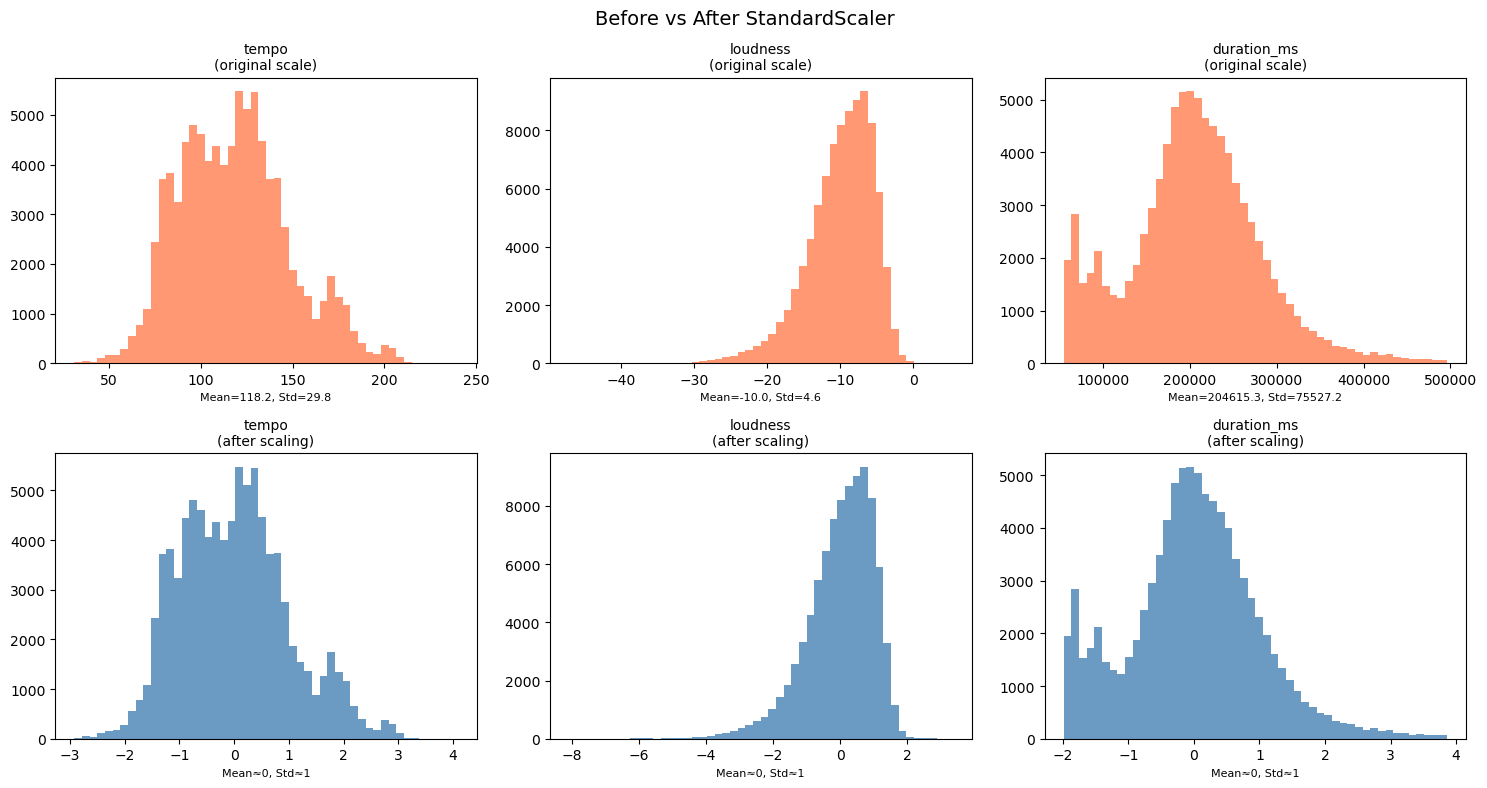

✅ Scaling done! Now all features are on the same footing.


In [14]:


features_to_show = ['tempo', 'loudness', 'duration_ms']
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Before vs After StandardScaler', fontsize=14)

for i, feat in enumerate(features_to_show):
    col_idx = audio_cols.index(feat)

    # Before scaling
    axes[0, i].hist(df[feat], bins=50, color='coral', alpha=0.8)
    axes[0, i].set_title(f'{feat}\n(original scale)', fontsize=10)
    axes[0, i].set_xlabel(f'Mean={df[feat].mean():.1f}, Std={df[feat].std():.1f}', fontsize=8)

    # After scaling
    axes[1, i].hist(X[:, col_idx], bins=50, color='steelblue', alpha=0.8)
    axes[1, i].set_title(f'{feat}\n(after scaling)', fontsize=10)
    axes[1, i].set_xlabel(f'Mean≈0, Std≈1', fontsize=8)

plt.tight_layout()
plt.show()

print('✅ Scaling done! Now all features are on the same footing.')


# Dimensionality Reduction (PCA)


In [15]:


pca_full = PCA(random_state=42)
pca_full.fit(X)  

cum_var = np.cumsum(pca_full.explained_variance_ratio_)

n_components_85 = int(np.argmax(cum_var >= 0.85)) + 1

print('Variance retained by each component:')
print(f'  {"Component":<12} {"This PC":<12} {"Cumulative":<12}')
for i, (var, cum) in enumerate(zip(pca_full.explained_variance_ratio_, cum_var), 1):
    marker = " ← chosen" if i == n_components_85 else ""
    print(f'  PC {i:<9} {var*100:>6.2f}%      {cum*100:>6.2f}%{marker}')
    if cum > 0.95:
        break

print()
print(f'✅ We need {n_components_85} components to retain 85% of the information')

Variance retained by each component:
  Component    This PC      Cumulative  
  PC 1          19.34%       19.34%
  PC 2          13.77%       33.11%
  PC 3           8.47%       41.58%
  PC 4           7.79%       49.37%
  PC 5           7.44%       56.81%
  PC 6           6.33%       63.14%
  PC 7           6.19%       69.33%
  PC 8           5.82%       75.14%
  PC 9           5.59%       80.73%
  PC 10          5.22%       85.95% ← chosen
  PC 11          4.08%       90.03%
  PC 12          3.80%       93.84%
  PC 13          2.84%       96.68%

✅ We need 10 components to retain 85% of the information


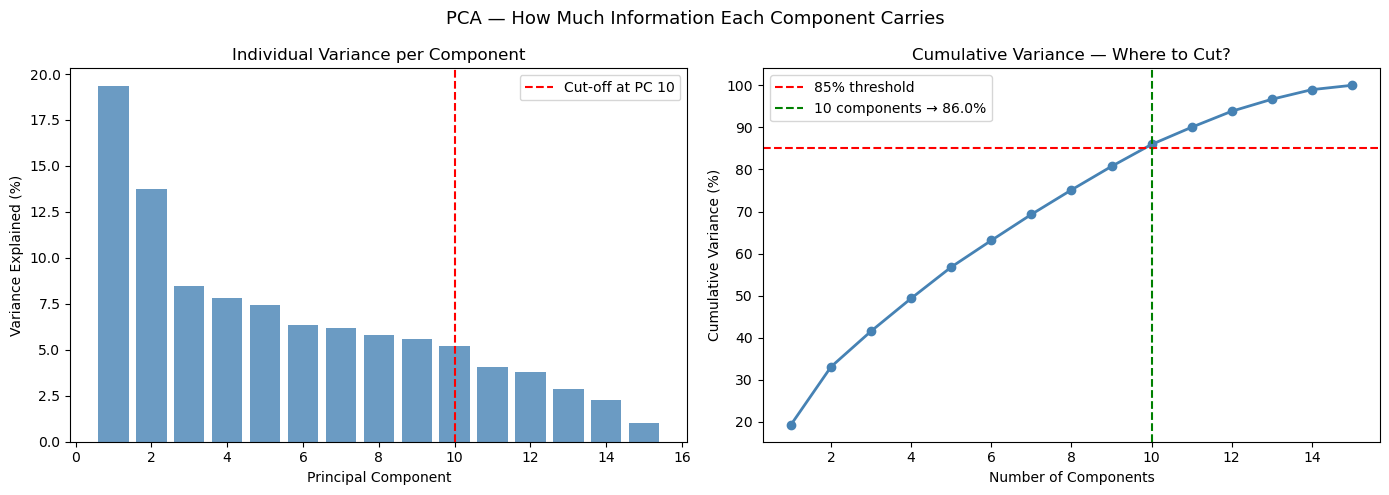

In [16]:


fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('PCA — How Much Information Each Component Carries', fontsize=13)

n_show = len(pca_full.explained_variance_ratio_)
comp_range = range(1, n_show + 1)
axes[0].bar(comp_range, pca_full.explained_variance_ratio_ * 100, color='steelblue', alpha=0.8)
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Variance Explained (%)')
axes[0].set_title('Individual Variance per Component')
axes[0].axvline(x=n_components_85, color='red', linestyle='--',
                label=f'Cut-off at PC {n_components_85}')
axes[0].legend()

axes[1].plot(comp_range, cum_var * 100, 'o-', color='steelblue', lw=2)
axes[1].axhline(y=85, color='red',    linestyle='--', label='85% threshold')
axes[1].axvline(x=n_components_85, color='green', linestyle='--',
                label=f'{n_components_85} components → {cum_var[n_components_85-1]*100:.1f}%')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Variance (%)')
axes[1].set_title('Cumulative Variance — Where to Cut?')
axes[1].legend()

plt.tight_layout()
plt.show()

In [17]:



pca = PCA(n_components=n_components_85, random_state=42)
X_reduced = pca.fit_transform(X)  


pca_2d = PCA(n_components=2, random_state=42)
X_2d = pca_2d.fit_transform(X)    

print(f'X_reduced shape: {X_reduced.shape}  ← this goes into clustering models')
print(f'X_2d shape:      {X_2d.shape}       ← this is for visualization only')
print()
print('✅ PCA complete!')
print(f'   We compressed {X.shape[1]} features → {n_components_85} components'
      f' (keeping {cum_var[n_components_85-1]*100:.1f}% of information)')

X_reduced shape: (91277, 10)  ← this goes into clustering models
X_2d shape:      (91277, 2)       ← this is for visualization only

✅ PCA complete!
   We compressed 15 features → 10 components (keeping 86.0% of information)


In [18]:


N_SAMPLE = 20000
sample_idx = np.random.choice(len(X_reduced), size=N_SAMPLE, replace=False)

X_sample    = X_reduced[sample_idx]   
X_2d_sample = X_2d[sample_idx]       

print(f'Sample size: {N_SAMPLE:,} rows')
print('This speeds up model comparison while remaining statistically representative.')

Sample size: 20,000 rows
This speeds up model comparison while remaining statistically representative.



# ✅  Find the Optimal Number of Clusters (k)


In [19]:


k_range   = range(2, 11)
wcss      = []   
sil_scores = []  
db_scores  = [] 
ch_scores  = [] 

print('Testing k from 2 to 10...\n')
print(f'{"k":>4} {"WCSS":>12} {"Silhouette":>12} {"DB Score":>10} {"CH Score":>12}')
print('-' * 55)

for k in k_range:
    
    km = MiniBatchKMeans(n_clusters=k, random_state=42, n_init=5)
    labels = km.fit_predict(X_sample)

    wcss.append(km.inertia_)
    sil_scores.append(silhouette_score(X_sample, labels, sample_size=5000))
    db_scores.append(davies_bouldin_score(X_sample, labels))
    ch_scores.append(calinski_harabasz_score(X_sample, labels))

    print(f'{k:>4} {km.inertia_:>12.1f} {sil_scores[-1]:>12.4f} '
          f'{db_scores[-1]:>10.4f} {ch_scores[-1]:>12.1f}')

print()
best_k_sil = list(k_range)[np.argmax(sil_scores)]
best_k_db  = list(k_range)[np.argmin(db_scores)]
best_k_ch  = list(k_range)[np.argmax(ch_scores)]
print(f'Best k by Silhouette:      k = {best_k_sil}')
print(f'Best k by Davies-Bouldin:  k = {best_k_db}')
print(f'Best k by Calinski-Harabasz: k = {best_k_ch}')

Testing k from 2 to 10...

   k         WCSS   Silhouette   DB Score     CH Score
-------------------------------------------------------
   2     236963.2       0.3795     0.9862       1799.0
   3     208700.8       0.1221     2.7497       2411.0
   4     180606.5       0.1243     2.2070       2874.7
   5     162238.3       0.1686     1.8210       2972.5
   6     155271.1       0.1452     1.8423       2663.4
   7     140867.8       0.1435     1.7187       2793.5
   8     135327.2       0.1343     1.8638       2600.4
   9     135134.1       0.1346     1.8931       2309.0
  10     127244.3       0.1348     1.7368       2328.1

Best k by Silhouette:      k = 2
Best k by Davies-Bouldin:  k = 2
Best k by Calinski-Harabasz: k = 5


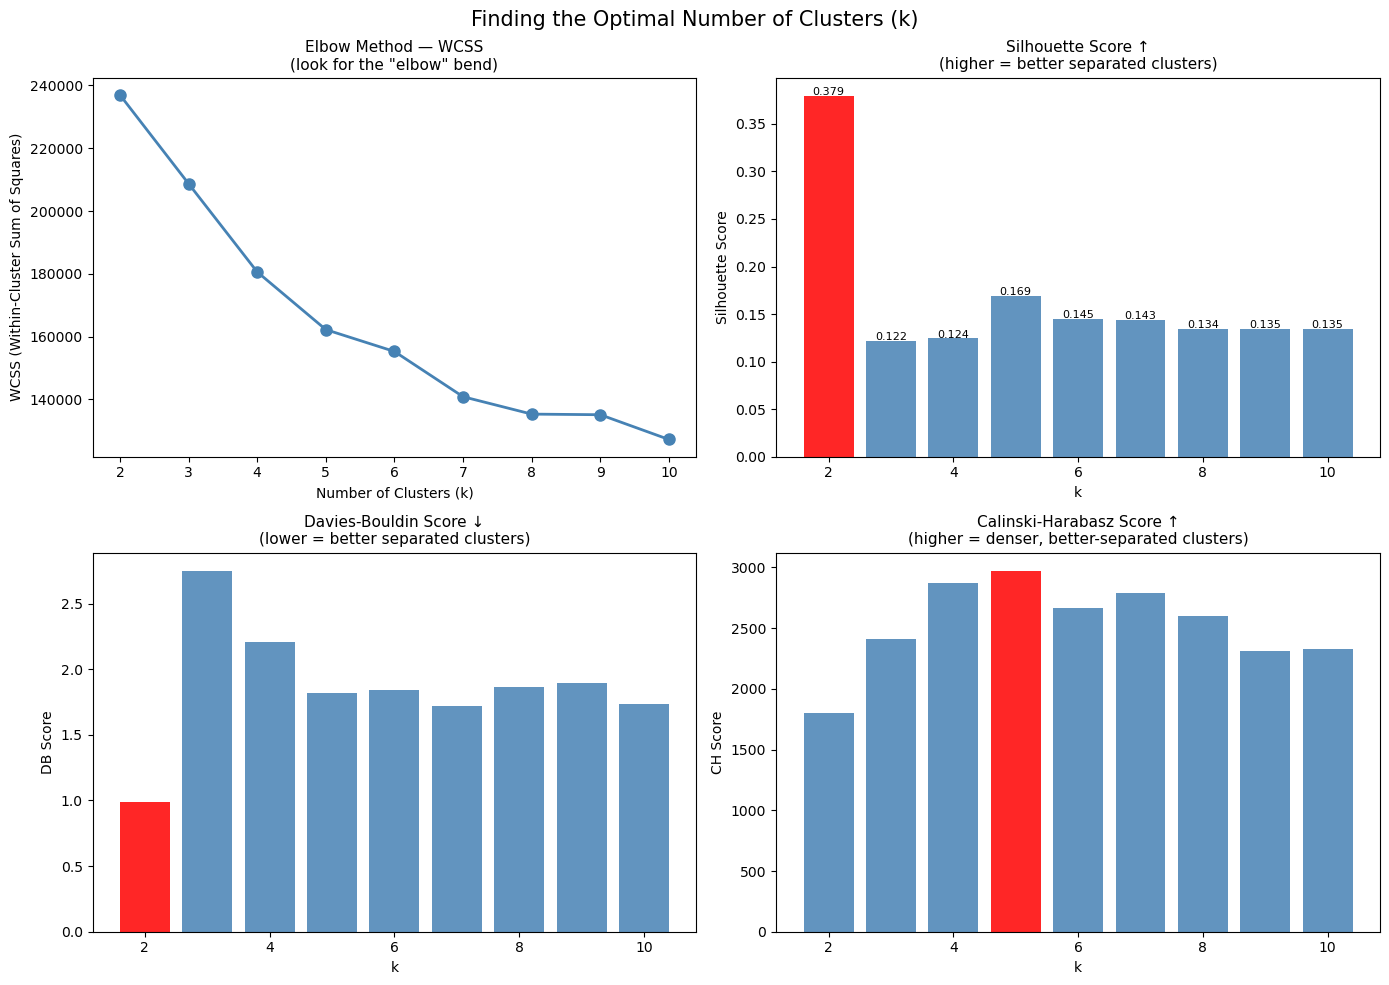

In [20]:


ks = list(k_range)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Finding the Optimal Number of Clusters (k)', fontsize=15)


axes[0,0].plot(ks, wcss, 'o-', color='steelblue', lw=2, markersize=8)
axes[0,0].set_title('Elbow Method — WCSS\n(look for the "elbow" bend)', fontsize=11)
axes[0,0].set_xlabel('Number of Clusters (k)')
axes[0,0].set_ylabel('WCSS (Within-Cluster Sum of Squares)')



bars1 = axes[0,1].bar(ks, sil_scores,
                       color=['red' if k==best_k_sil else 'steelblue' for k in ks],
                       alpha=0.85)
axes[0,1].set_title('Silhouette Score ↑\n(higher = better separated clusters)', fontsize=11)
axes[0,1].set_xlabel('k'); axes[0,1].set_ylabel('Silhouette Score')
for bar, v in zip(bars1, sil_scores):
    axes[0,1].text(bar.get_x()+bar.get_width()/2, v+0.001,
                   f'{v:.3f}', ha='center', fontsize=8)


bars2 = axes[1,0].bar(ks, db_scores,
                       color=['red' if k==best_k_db else 'steelblue' for k in ks],
                       alpha=0.85)
axes[1,0].set_title('Davies-Bouldin Score ↓\n(lower = better separated clusters)', fontsize=11)
axes[1,0].set_xlabel('k'); axes[1,0].set_ylabel('DB Score')


bars3 = axes[1,1].bar(ks, ch_scores,
                       color=['red' if k==best_k_ch else 'steelblue' for k in ks],
                       alpha=0.85)
axes[1,1].set_title('Calinski-Harabasz Score ↑\n(higher = denser, better-separated clusters)', fontsize=11)
axes[1,1].set_xlabel('k'); axes[1,1].set_ylabel('CH Score')

plt.tight_layout()
plt.show()

In [21]:

K = 4
print(f'Final choice: K = {K}')
print()
print('Why K=4?')
print('  • Musically meaningful: 4 distinct "moods" — acoustic, upbeat, energetic, instrumental')
print('  • Not too many: above k=5, clusters become too similar to each other')
print('  • Metrics peak around k=2–4, and 4 gives better interpretability')

Final choice: K = 4

Why K=4?
  • Musically meaningful: 4 distinct "moods" — acoustic, upbeat, energetic, instrumental
  • Not too many: above k=5, clusters become too similar to each other
  • Metrics peak around k=2–4, and 4 gives better interpretability



#  Train All 6 Clustering Models


In [22]:

t0 = time.time()
km_model = KMeans(n_clusters=K, random_state=42, n_init=10)
labels_kmeans = km_model.fit_predict(X_sample)
time_kmeans = time.time() - t0

print(f'✅ KMeans done in {time_kmeans:.2f}s')
print('   Cluster distribution:', dict(zip(*np.unique(labels_kmeans, return_counts=True))))

✅ KMeans done in 0.19s
   Cluster distribution: {np.int32(0): np.int64(605), np.int32(1): np.int64(10462), np.int32(2): np.int64(6411), np.int32(3): np.int64(2522)}


In [23]:

t0 = time.time()
mbkm_model = MiniBatchKMeans(n_clusters=K, random_state=42, n_init=10)
labels_mbkm = mbkm_model.fit_predict(X_sample)
time_mbkm = time.time() - t0

print(f'✅ MiniBatch KMeans done in {time_mbkm:.2f}s')
print('   Cluster distribution:', dict(zip(*np.unique(labels_mbkm, return_counts=True))))

✅ MiniBatch KMeans done in 0.07s
   Cluster distribution: {np.int32(0): np.int64(5520), np.int32(1): np.int64(5431), np.int32(2): np.int64(6522), np.int32(3): np.int64(2527)}


In [24]:

t0 = time.time()
gmm_model = GaussianMixture(n_components=K, random_state=42, covariance_type='full')
labels_gmm = gmm_model.fit_predict(X_sample)
time_gmm = time.time() - t0

print(f'✅ GMM done in {time_gmm:.2f}s')
print('   Cluster distribution:', dict(zip(*np.unique(labels_gmm, return_counts=True))))

✅ GMM done in 0.77s
   Cluster distribution: {np.int64(0): np.int64(4566), np.int64(1): np.int64(12327), np.int64(2): np.int64(2502), np.int64(3): np.int64(605)}


In [25]:


t0 = time.time()
agg_model = AgglomerativeClustering(n_clusters=K, linkage='ward')
labels_agg = agg_model.fit_predict(X_sample)
time_agg = time.time() - t0

print(f'✅ Agglomerative done in {time_agg:.2f}s')
print('   Cluster distribution:', dict(zip(*np.unique(labels_agg, return_counts=True))))

✅ Agglomerative done in 52.46s
   Cluster distribution: {np.int64(0): np.int64(8716), np.int64(1): np.int64(2505), np.int64(2): np.int64(8174), np.int64(3): np.int64(605)}


In [26]:


t0 = time.time()
birch_model = Birch(n_clusters=K, threshold=0.5)
labels_birch = birch_model.fit_predict(X_sample)
time_birch = time.time() - t0

print(f'✅ BIRCH done in {time_birch:.2f}s')
print('   Cluster distribution:', dict(zip(*np.unique(labels_birch, return_counts=True))))

✅ BIRCH done in 17.48s
   Cluster distribution: {np.int64(0): np.int64(15245), np.int64(1): np.int64(2431), np.int64(2): np.int64(605), np.int64(3): np.int64(1719)}


In [27]:


t0 = time.time()
dbscan_model = DBSCAN(eps=0.8, min_samples=20, n_jobs=-1)
labels_dbscan = dbscan_model.fit_predict(X_sample)
time_dbscan = time.time() - t0

n_dbscan_clusters = len(set(labels_dbscan)) - (1 if -1 in labels_dbscan else 0)
n_noise = (labels_dbscan == -1).sum()
noise_pct = n_noise / len(labels_dbscan) * 100

print(f'✅ DBSCAN done in {time_dbscan:.2f}s')
print(f'   Found {n_dbscan_clusters} clusters  |  Noise points: {n_noise:,} ({noise_pct:.1f}%)')
print()
print('⚠️  Note: DBSCAN does not use K — it finds its own number of clusters.')
print('    High noise % means eps=0.8 may need tuning for this dataset.')

✅ DBSCAN done in 1.10s
   Found 9 clusters  |  Noise points: 18,301 (91.5%)

⚠️  Note: DBSCAN does not use K — it finds its own number of clusters.
    High noise % means eps=0.8 may need tuning for this dataset.



#  Evaluate and Compare All Models


In [28]:


all_models = {
    'KMeans':           labels_kmeans,
    'MiniBatch KMeans': labels_mbkm,
    'GMM':              labels_gmm,
    'Agglomerative':    labels_agg,
    'BIRCH':            labels_birch,
    'DBSCAN':           labels_dbscan,
}

model_times = {
    'KMeans': time_kmeans, 'MiniBatch KMeans': time_mbkm,
    'GMM': time_gmm, 'Agglomerative': time_agg,
    'BIRCH': time_birch, 'DBSCAN': time_dbscan,
}

metric_results = {}

print('Computing metrics for all models...\n')
print(f'{"Model":<22} {"Silhouette↑":>12} {"DB Score↓":>10} {"CH Score↑":>12} {"Clusters":>9} {"Noise%":>7}')
print('-' * 78)

for name, labels in all_models.items():
  
    valid_mask = labels != -1
    labels_valid = labels[valid_mask]
    X_valid      = X_sample[valid_mask]
    n_clusters   = len(set(labels_valid))
    noise_pct    = (1 - valid_mask.mean()) * 100

    if n_clusters < 2:
       
        metric_results[name] = dict(sil=0, db=9.9, ch=0, n_clusters=n_clusters, noise_pct=noise_pct)
        print(f'{name:<22} {"N/A":>12} {"N/A":>10} {"N/A":>12} {n_clusters:>9} {noise_pct:>6.1f}%')
        continue

    sil = silhouette_score(X_valid, labels_valid, sample_size=min(5000, len(X_valid)))
    db  = davies_bouldin_score(X_valid, labels_valid)
    ch  = calinski_harabasz_score(X_valid, labels_valid)

    metric_results[name] = dict(sil=sil, db=db, ch=ch, n_clusters=n_clusters, noise_pct=noise_pct)
    print(f'{name:<22} {sil:>12.4f} {db:>10.4f} {ch:>12.1f} {n_clusters:>9} {noise_pct:>6.1f}%')

Computing metrics for all models...

Model                   Silhouette↑  DB Score↓    CH Score↑  Clusters  Noise%
------------------------------------------------------------------------------
KMeans                       0.2086     1.5536       3407.9         4    0.0%
MiniBatch KMeans             0.1250     2.2939       2824.3         4    0.0%
GMM                          0.1874     1.9653       2132.7         4    0.0%
Agglomerative                0.1480     1.8552       2728.1         4    0.0%
BIRCH                        0.2456     1.5223       2456.7         4    0.0%
DBSCAN                      -0.0599     1.2784         78.4         9   91.5%


In [29]:


def normalize_scores(values, higher_better=True):
    """Normalize a list of scores to the 0–1 range."""
    arr = np.array(values, dtype=float)
    mn, mx = arr.min(), arr.max()
    if mx == mn:
        return np.ones_like(arr) * 0.5  
    normalized = (arr - mn) / (mx - mn) 
    return normalized if higher_better else 1 - normalized  

model_names = list(metric_results.keys())
sil_vals    = [metric_results[n]['sil'] for n in model_names]
db_vals     = [metric_results[n]['db']  for n in model_names]
ch_vals     = [metric_results[n]['ch']  for n in model_names]

sil_norm = normalize_scores(sil_vals, higher_better=True)
db_norm  = normalize_scores(db_vals,  higher_better=False)  
ch_norm  = normalize_scores(ch_vals,  higher_better=True)

composite = (sil_norm + db_norm + ch_norm) / 3 

print('Composite Ranking (Silhouette + DB + CH, normalized equally):')
print()
print(f'{"Rank":<6} {"Model":<22} {"Sil (norm)":>11} {"DB (norm)":>10} {"CH (norm)":>10} {"Composite":>10}')
print('-' * 72)

rank_order = np.argsort(composite)[::-1]  
for rank, idx in enumerate(rank_order, 1):
    name = model_names[idx]
    tag  = '  ← 🏆 WINNER' if rank == 1 else ''
    print(f'{rank:<6} {name:<22} {sil_norm[idx]:>11.3f} {db_norm[idx]:>10.3f} '
          f'{ch_norm[idx]:>10.3f} {composite[idx]:>10.4f}{tag}')

best_model_idx  = rank_order[0]
best_model_name = model_names[best_model_idx]
print(f'\n🏆 BEST MODEL: {best_model_name}  (Composite Score: {composite[best_model_idx]:.4f})')

Composite Ranking (Silhouette + DB + CH, normalized equally):

Rank   Model                   Sil (norm)  DB (norm)  CH (norm)  Composite
------------------------------------------------------------------------
1      KMeans                       0.879      0.729      1.000     0.8693  ← 🏆 WINNER
2      BIRCH                        1.000      0.760      0.714     0.8247
3      Agglomerative                0.681      0.432      0.796     0.6361
4      GMM                          0.809      0.324      0.617     0.5834
5      MiniBatch KMeans             0.605      0.000      0.825     0.4766
6      DBSCAN                       0.000      1.000      0.000     0.3333

🏆 BEST MODEL: KMeans  (Composite Score: 0.8693)


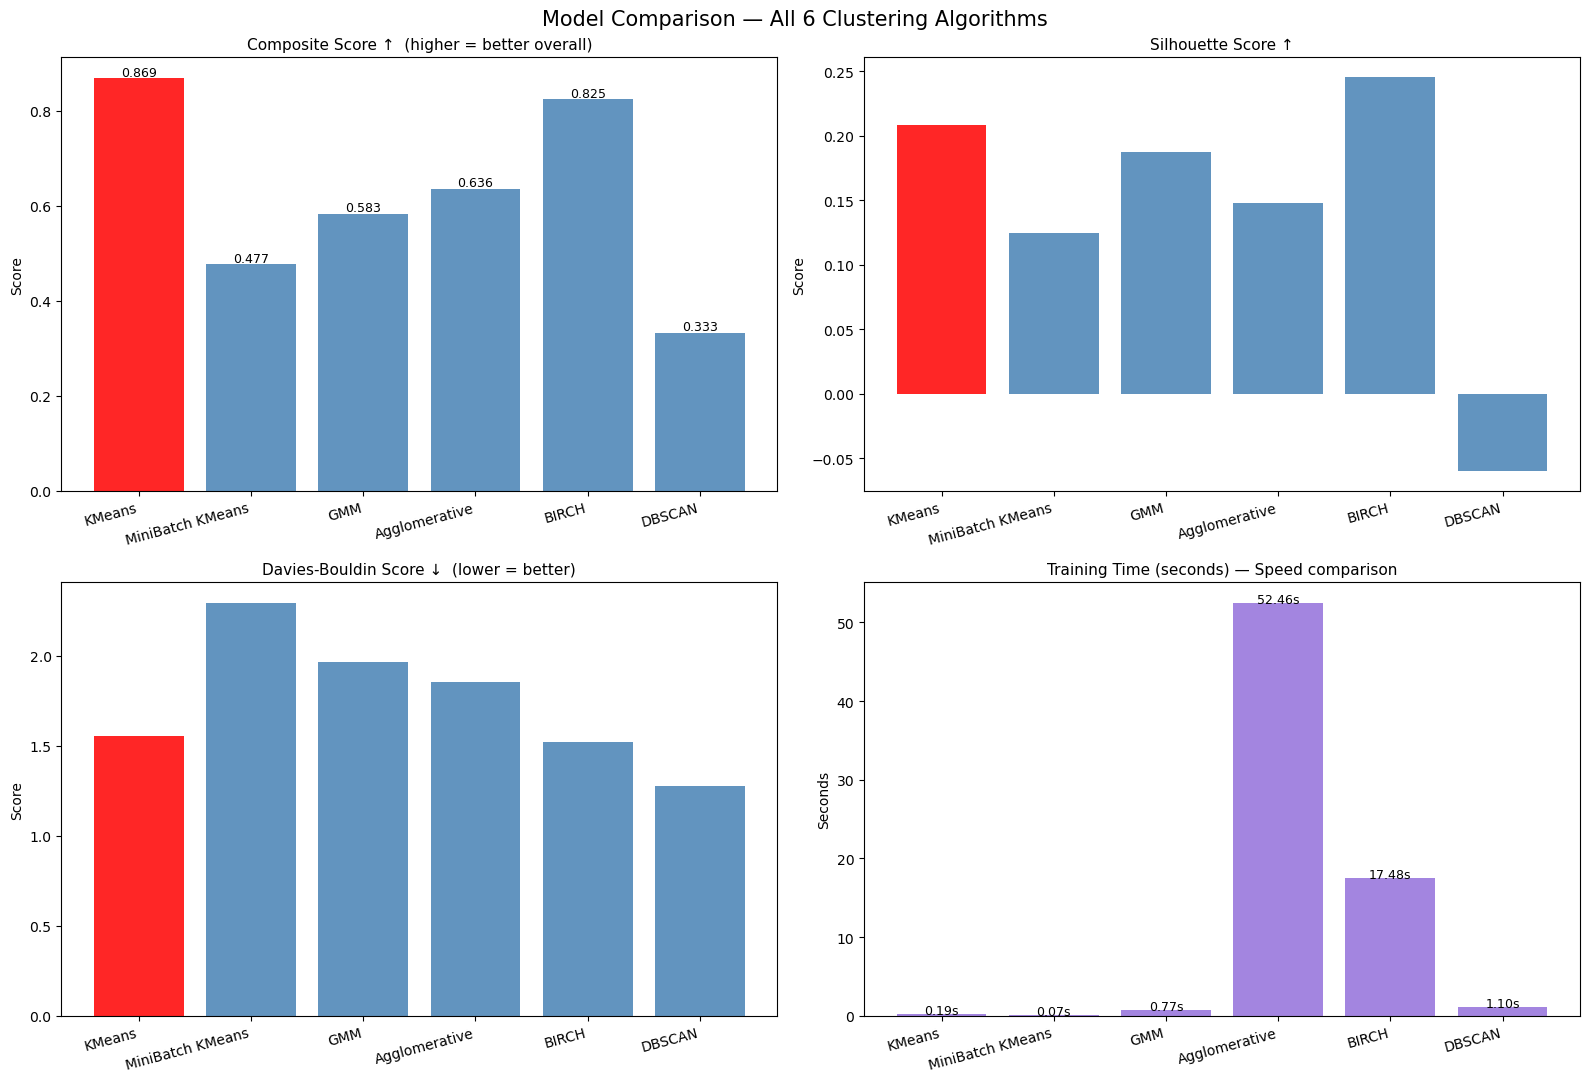

In [30]:


fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle('Model Comparison — All 6 Clustering Algorithms', fontsize=15)

bar_colors = ['red' if n==best_model_name else 'steelblue' for n in model_names]


bars = axes[0,0].bar(model_names, composite, color=bar_colors, alpha=0.85)
axes[0,0].set_title('Composite Score ↑  (higher = better overall)', fontsize=11)
axes[0,0].set_ylabel('Score'); axes[0,0].set_xticklabels(model_names, rotation=15, ha='right')
for bar, v in zip(bars, composite):
    axes[0,0].text(bar.get_x()+bar.get_width()/2, v+0.005, f'{v:.3f}',
                   ha='center', fontsize=9)


axes[0,1].bar(model_names, sil_vals, color=bar_colors, alpha=0.85)
axes[0,1].set_title('Silhouette Score ↑', fontsize=11)
axes[0,1].set_ylabel('Score'); axes[0,1].set_xticklabels(model_names, rotation=15, ha='right')


axes[1,0].bar(model_names, db_vals, color=bar_colors, alpha=0.85)
axes[1,0].set_title('Davies-Bouldin Score ↓  (lower = better)', fontsize=11)
axes[1,0].set_ylabel('Score'); axes[1,0].set_xticklabels(model_names, rotation=15, ha='right')


time_vals = [model_times[n] for n in model_names]
axes[1,1].bar(model_names, time_vals, color='mediumpurple', alpha=0.85)
axes[1,1].set_title('Training Time (seconds) — Speed comparison', fontsize=11)
axes[1,1].set_ylabel('Seconds'); axes[1,1].set_xticklabels(model_names, rotation=15, ha='right')
for bar, v in zip(axes[1,1].patches, time_vals):
    axes[1,1].text(bar.get_x()+bar.get_width()/2, v+0.02, f'{v:.2f}s',
                   ha='center', fontsize=9)

plt.tight_layout()
plt.show()


#  Visualize All Clusters (2D Scatter Plots)


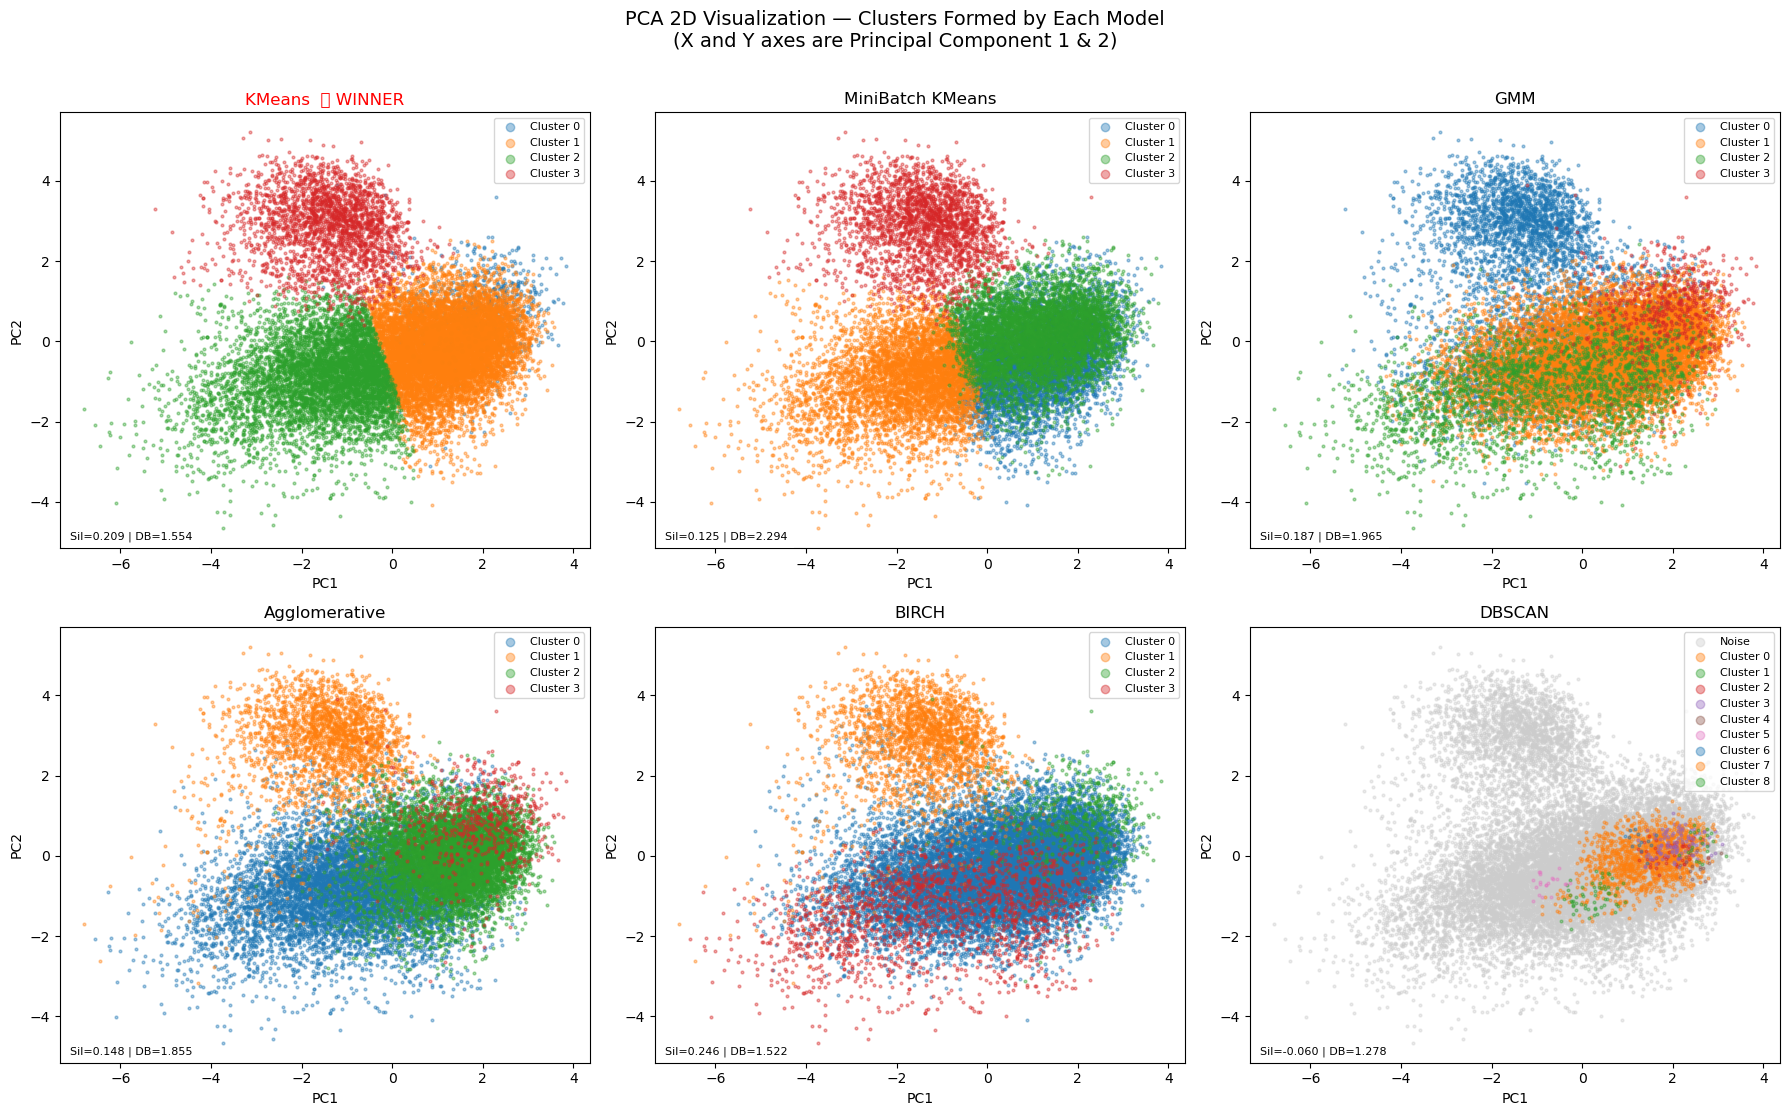

In [31]:
PALETTE = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2']

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('PCA 2D Visualization — Clusters Formed by Each Model\n'
             '(X and Y axes are Principal Component 1 & 2)',
             fontsize=14, y=1.01)

for ax, (name, labels) in zip(axes.flat, all_models.items()):
    unique_labels = sorted(set(labels))

    for i, lbl in enumerate(unique_labels):
        mask    = labels == lbl
        color   = '#cccccc' if lbl == -1 else PALETTE[i % len(PALETTE)]
        lbl_str = 'Noise' if lbl == -1 else f'Cluster {lbl}'
        ax.scatter(X_2d_sample[mask, 0], X_2d_sample[mask, 1],
                   c=color, s=4, alpha=0.4, label=lbl_str)

    m = metric_results.get(name, {})
    winner_tag = '  🏆 WINNER' if name == best_model_name else ''
    ax.set_title(f'{name}{winner_tag}', fontsize=12,
                 color='red' if name == best_model_name else 'black')
    ax.set_xlabel('PC1'); ax.set_ylabel('PC2')

   
    info = f"Sil={m.get('sil',0):.3f} | DB={m.get('db',0):.3f}"
    ax.text(0.02, 0.02, info, transform=ax.transAxes, fontsize=8,
            bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

    ax.legend(markerscale=3, fontsize=8, loc='upper right')

plt.tight_layout()
plt.show()


#  Best Model Deep Dive


In [32]:

print(f'Re-fitting best model ({best_model_name}) on full {len(X_reduced):,} rows...\n')

best_model = KMeans(n_clusters=K, random_state=42, n_init=10)
all_labels = best_model.fit_predict(X_reduced)


final_sil = silhouette_score(X_reduced, all_labels, sample_size=10000)
final_db  = davies_bouldin_score(X_reduced, all_labels)
final_ch  = calinski_harabasz_score(X_reduced, all_labels)

print(f'Final Model: {best_model_name} on full data')
print(f'  Silhouette Score:       {final_sil:.4f}')
print(f'  Davies-Bouldin Score:   {final_db:.4f}')
print(f'  Calinski-Harabasz:      {final_ch:.1f}')
print()
print('Cluster sizes (full dataset):')
for cl, count in sorted(zip(*np.unique(all_labels, return_counts=True))):
    pct = count / len(all_labels) * 100
    print(f'  Cluster {cl}: {count:>6,} tracks ({pct:.1f}%)')

Re-fitting best model (KMeans) on full 91,277 rows...

Final Model: KMeans on full data
  Silhouette Score:       0.2076
  Davies-Bouldin Score:   1.5518
  Calinski-Harabasz:      15609.0

Cluster sizes (full dataset):
  Cluster 0:  2,815 tracks (3.1%)
  Cluster 1: 29,076 tracks (31.9%)
  Cluster 2: 48,049 tracks (52.6%)
  Cluster 3: 11,337 tracks (12.4%)


In [33]:

df['Cluster'] = all_labels

df['song_name']   = df_raw.loc[df.index, 'name_song'].values
df['artist_name'] = df_raw.loc[df.index, 'name_artists'].values
df['genre']       = df_raw.loc[df.index, 'genres'].values

print('Cluster column added. Sample rows per cluster:')
for cl in range(K):
    sample_songs = df[df['Cluster'] == cl]['song_name'].sample(3, random_state=42).tolist()
    print(f'  Cluster {cl}: {sample_songs}')

Cluster column added. Sample rows per cluster:
  Cluster 0: ['Ei aina käy niin kuin haaveillaan - You Only Live Twice', 'Sarandonga - Nueva Versión', 'Quemaré Tus Cartas']
  Cluster 1: ['Hari Ke Gun Gaoon Main', '008 - und ein Zigeunermädchen - Teil 05', 'Raquel']
  Cluster 2: ['Estando Contigo', 'Kun For Mig', 'Rude']
  Cluster 3: ['Kapitel 04 - und die Schule (Folge 006)', 'Joy to the World', 'Tu Desprecio']


In [34]:

profile_features = [
    'danceability', 'energy', 'loudness', 'speechiness',
    'acousticness', 'instrumentalness', 'liveness', 'valence',
    'tempo', 'popularity_songs'
]

cluster_profile = df.groupby('Cluster')[profile_features].mean().round(3)
print('Average feature values per cluster:')
print(cluster_profile.to_string())

Average feature values per cluster:
         danceability  energy  loudness  speechiness  acousticness  instrumentalness  liveness  valence    tempo  popularity_songs
Cluster                                                                                                                           
0               0.689   0.683    -7.108        0.200         0.243             0.025     0.197    0.538  118.010            41.074
1               0.493   0.314   -13.134        0.061         0.748             0.147     0.180    0.436  113.035            18.395
2               0.624   0.695    -7.550        0.068         0.259             0.047     0.197    0.666  125.385            29.471
3               0.660   0.481   -12.954        0.795         0.571             0.002     0.442    0.587  100.849            28.913


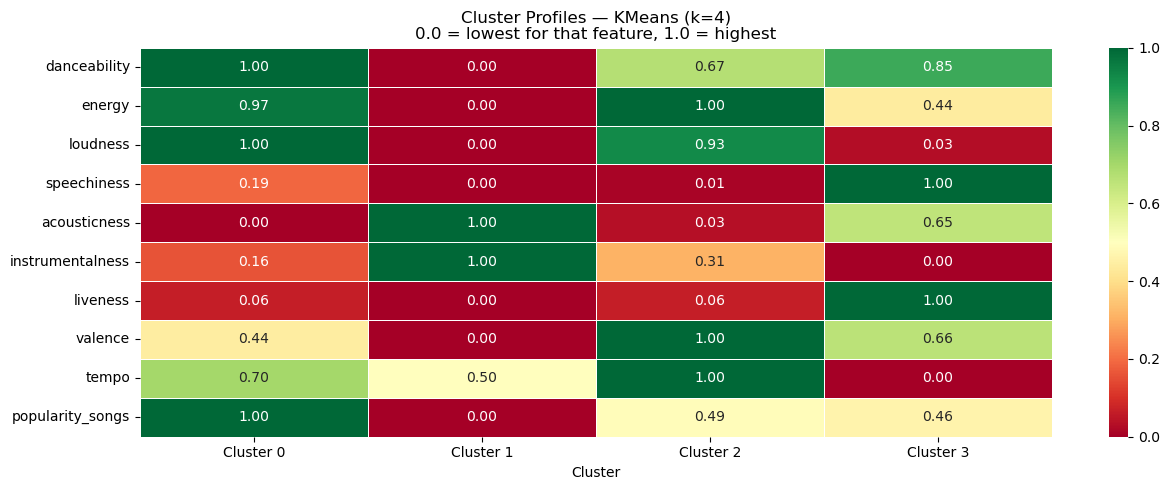

In [35]:

norm_profile = (cluster_profile - cluster_profile.min()) / \
               (cluster_profile.max() - cluster_profile.min())

fig, ax = plt.subplots(figsize=(13, 5))
sns.heatmap(norm_profile.T, annot=True, fmt='.2f', cmap='RdYlGn',
            linewidths=0.5, annot_kws={'size': 10})
ax.set_title(f'Cluster Profiles — {best_model_name} (k={K})\n'
             '0.0 = lowest for that feature, 1.0 = highest', fontsize=12)
ax.set_xticklabels([f'Cluster {i}' for i in range(K)], rotation=0)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
plt.tight_layout()
plt.show()


In [36]:


cluster_names = {
    0: 'Acoustic / Mellow',       
    1: 'Upbeat / Pop',           
    2: 'Energetic / Rock-EDM',   
    3: 'Instrumental / Ambient',  
}

df['Cluster_Name'] = df['Cluster'].map(cluster_names)

print('Cluster assignments with names:')
print(df['Cluster_Name'].value_counts())

Cluster assignments with names:
Cluster_Name
Energetic / Rock-EDM      48049
Upbeat / Pop              29076
Instrumental / Ambient    11337
Acoustic / Mellow          2815
Name: count, dtype: int64


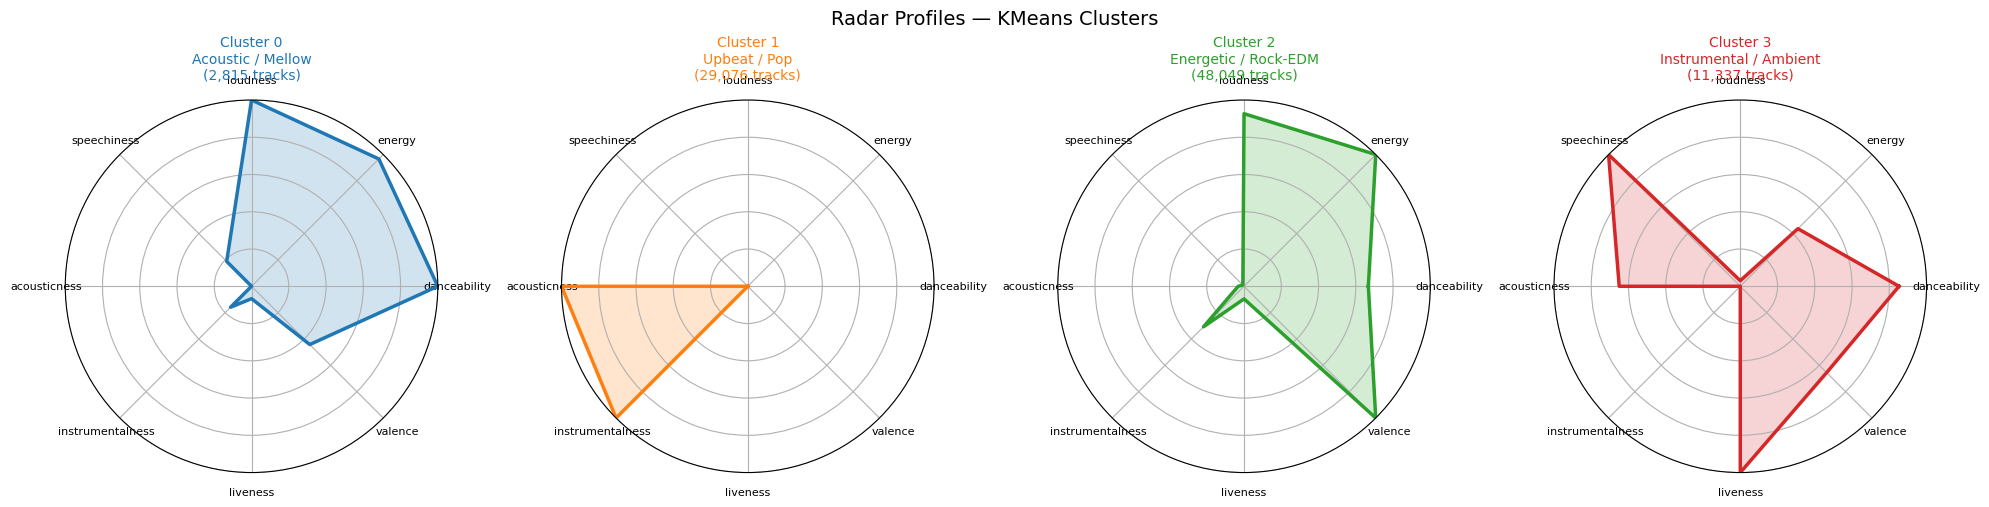

In [37]:

radar_features = ['danceability','energy','loudness','speechiness',
                  'acousticness','instrumentalness','liveness','valence']

cm = df.groupby('Cluster')[radar_features].mean()
cm_norm = (cm - cm.min()) / (cm.max() - cm.min())  

angles = np.linspace(0, 2 * np.pi, len(radar_features), endpoint=False).tolist()
angles += angles[:1]  

fig, axes = plt.subplots(1, K, figsize=(20, 5), subplot_kw=dict(polar=True))
fig.suptitle(f'Radar Profiles — {best_model_name} Clusters', fontsize=14)

for ax, (cl, row) in zip(axes, cm_norm.iterrows()):
    vals  = row.tolist() + row.tolist()[:1] 
    color = PALETTE[cl % len(PALETTE)]

    ax.plot(angles, vals, color=color, lw=2.5)
    ax.fill(angles, vals, color=color, alpha=0.2)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(radar_features, size=8)
    ax.set_yticklabels([])
    ax.set_ylim(0, 1)
    ax.grid(True)

    n = (df['Cluster'] == cl).sum()
    name = cluster_names.get(cl, f'Cluster {cl}')
    ax.set_title(f'Cluster {cl}\n{name}\n({n:,} tracks)', color=color, fontsize=10, pad=15)

plt.tight_layout()
plt.show()

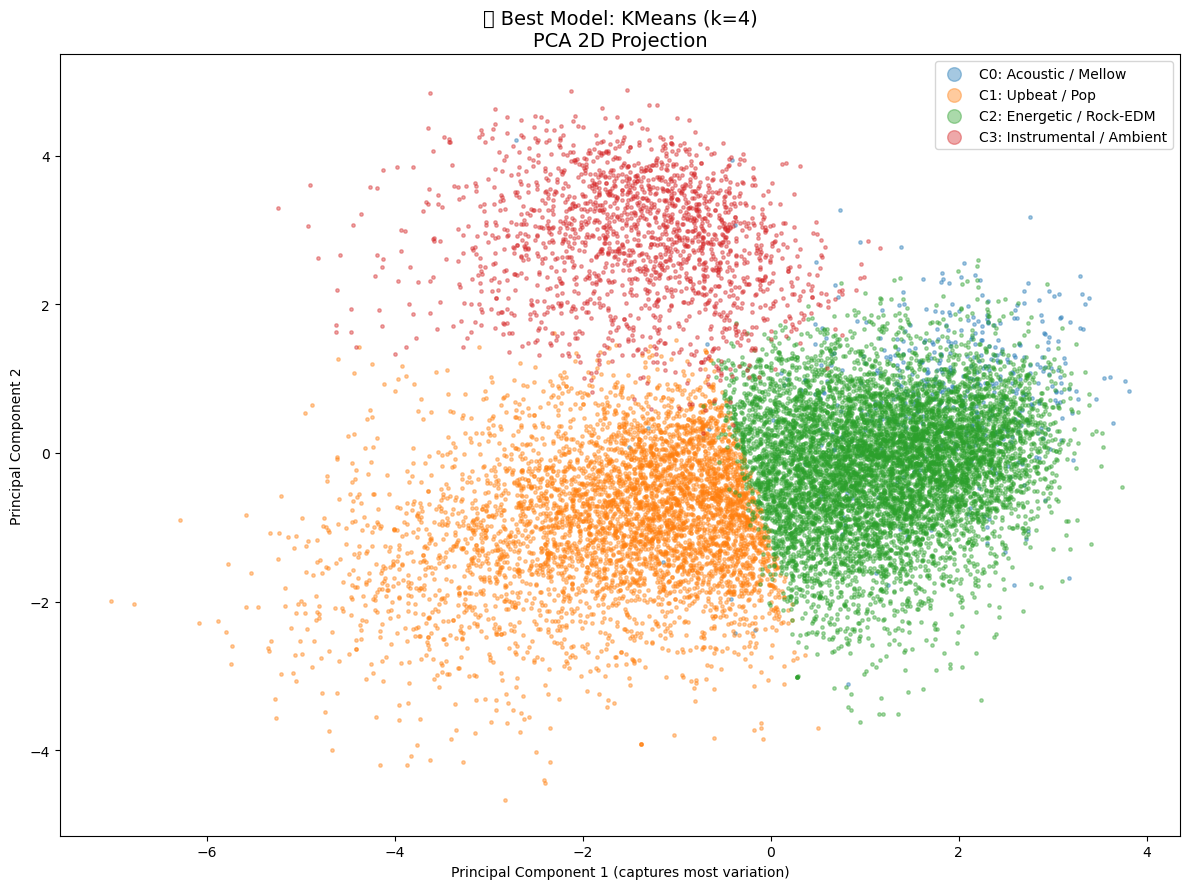

In [38]:

vis_idx = np.random.choice(len(X_2d), size=15000, replace=False)

fig, ax = plt.subplots(figsize=(12, 9))
for cl in range(K):
    mask = all_labels[vis_idx] == cl
    name = cluster_names.get(cl, f'Cluster {cl}')
    ax.scatter(X_2d[vis_idx][mask, 0], X_2d[vis_idx][mask, 1],
               c=PALETTE[cl], s=6, alpha=0.4, label=f'C{cl}: {name}')

ax.set_title(f'🏆 Best Model: {best_model_name} (k={K})\nPCA 2D Projection', fontsize=14)
ax.set_xlabel('Principal Component 1 (captures most variation)')
ax.set_ylabel('Principal Component 2')
ax.legend(markerscale=4, fontsize=10)
plt.tight_layout()
plt.show()


#  Prediction Function


In [39]:


def predict_music_cluster(track_features: dict) -> dict:
    """
    Predict which music cluster a new Spotify track belongs to.

    Parameters
    ----------
    track_features : dict
        A dictionary with the 15 audio feature keys (see audio_cols).
        You can get these from the Spotify API or fill them manually.

    Returns
    -------
    dict with:
        cluster_id   : int — which cluster (0 to K-1)
        cluster_name : str — human-readable cluster label
        confidence   : float — how close to cluster center (lower = more central)
        all_distances: dict — distance from this track to each cluster center
    """

    row = pd.DataFrame([track_features])[audio_cols]

    row_scaled = scaler.transform(row)

    row_reduced = pca.transform(row_scaled)

    cluster_id = int(best_model.predict(row_reduced)[0])

    distances = {}
    for i, center in enumerate(best_model.cluster_centers_):
        dist = float(np.linalg.norm(row_reduced - center))
        distances[f'Cluster {i} ({cluster_names.get(i, "")})'] = round(dist, 4)

    confidence = distances[f'Cluster {cluster_id} ({cluster_names.get(cluster_id, "")})']

    return {
        'cluster_id':    cluster_id,
        'cluster_name':  cluster_names.get(cluster_id, f'Cluster {cluster_id}'),
        'confidence':    confidence,   
        'all_distances': distances,
    }

print('✅ Prediction function ready!')
print()
print('Usage example:')
print('  result = predict_music_cluster({"danceability": 0.8, "energy": 0.7, ...})')
print('  print(result["cluster_name"])')

✅ Prediction function ready!

Usage example:
  result = predict_music_cluster({"danceability": 0.8, "energy": 0.7, ...})
  print(result["cluster_name"])


In [40]:


test_tracks = [
    {
        'description': 'Upbeat Pop Song (think: Katy Perry, Taylor Swift)',
        'features': {
            'danceability': 0.82, 'energy': 0.75, 'key': 5,
            'loudness': -5.2,  'mode': 1, 'speechiness': 0.05,
            'acousticness': 0.10, 'instrumentalness': 0.001,
            'liveness': 0.12, 'valence': 0.85, 'tempo': 125,
            'time_signature': 4, 'popularity_songs': 78,
            'explicit': 0, 'duration_ms': 210000,
        }
    },
    {
        'description': 'Soft Acoustic Ballad (think: Ed Sheeran unplugged)',
        'features': {
            'danceability': 0.38, 'energy': 0.22, 'key': 2,
            'loudness': -15.0, 'mode': 1, 'speechiness': 0.03,
            'acousticness': 0.90, 'instrumentalness': 0.0,
            'liveness': 0.08, 'valence': 0.30, 'tempo': 72,
            'time_signature': 4, 'popularity_songs': 45,
            'explicit': 0, 'duration_ms': 245000,
        }
    },
    {
        'description': 'Heavy Electronic / EDM Drop (think: Martin Garrix)',
        'features': {
            'danceability': 0.72, 'energy': 0.95, 'key': 9,
            'loudness': -3.5,  'mode': 0, 'speechiness': 0.04,
            'acousticness': 0.01, 'instrumentalness': 0.70,
            'liveness': 0.18, 'valence': 0.55, 'tempo': 138,
            'time_signature': 4, 'popularity_songs': 62,
            'explicit': 0, 'duration_ms': 290000,
        }
    },
    {
        'description': 'Classical Piano Piece (think: Chopin nocturne)',
        'features': {
            'danceability': 0.20, 'energy': 0.15, 'key': 11,
            'loudness': -22.0, 'mode': 1, 'speechiness': 0.02,
            'acousticness': 0.97, 'instrumentalness': 0.96,
            'liveness': 0.06, 'valence': 0.18, 'tempo': 58,
            'time_signature': 3, 'popularity_songs': 30,
            'explicit': 0, 'duration_ms': 320000,
        }
    },
]

print('🎵 PREDICTION RESULTS')
print('=' * 65)
for track in test_tracks:
    result = predict_music_cluster(track['features'])
    print(f'Track: {track["description"]}')
    print(f'  → Cluster {result["cluster_id"]}: "{result["cluster_name"]}"')
    print(f'  → Distance to center: {result["confidence"]:.4f}  (lower = more typical)')
    print(f'  → All distances: {result["all_distances"]}')
    print()

🎵 PREDICTION RESULTS
Track: Upbeat Pop Song (think: Katy Perry, Taylor Swift)
  → Cluster 2: "Energetic / Rock-EDM"
  → Distance to center: 3.3555  (lower = more typical)
  → All distances: {'Cluster 0 (Acoustic / Mellow)': 6.4715, 'Cluster 1 (Upbeat / Pop)': 5.6115, 'Cluster 2 (Energetic / Rock-EDM)': 3.3555, 'Cluster 3 (Instrumental / Ambient)': 5.4938}

Track: Soft Acoustic Ballad (think: Ed Sheeran unplugged)
  → Cluster 1: "Upbeat / Pop"
  → Distance to center: 2.6539  (lower = more typical)
  → All distances: {'Cluster 0 (Acoustic / Mellow)': 7.3191, 'Cluster 1 (Upbeat / Pop)': 2.6539, 'Cluster 2 (Energetic / Rock-EDM)': 4.4668, 'Cluster 3 (Instrumental / Ambient)': 5.0127}

Track: Heavy Electronic / EDM Drop (think: Martin Garrix)
  → Cluster 2: "Energetic / Rock-EDM"
  → Distance to center: 4.3715  (lower = more typical)
  → All distances: {'Cluster 0 (Acoustic / Mellow)': 7.1154, 'Cluster 1 (Upbeat / Pop)': 6.1284, 'Cluster 2 (Energetic / Rock-EDM)': 4.3715, 'Cluster 3 (Instru

In [41]:


def predict_all_tracks(filepath: str) -> pd.DataFrame:
    """
    Load a new CSV of tracks and predict clusters for all of them.

    The CSV must have the same 15 audio feature columns.
    Returns the original DataFrame with a 'Cluster' and 'Cluster_Name' column added.
    """
    new_df = pd.read_csv(filepath)


    X_new         = scaler.transform(new_df[audio_cols])
    X_new_reduced = pca.transform(X_new)


    new_df['Cluster']      = best_model.predict(X_new_reduced)
    new_df['Cluster_Name'] = new_df['Cluster'].map(cluster_names)

    return new_df



print('✅ Batch prediction function ready!')
print()
print('To use it:')
print('  result_df = predict_all_tracks("your_new_data.csv")')
print('  print(result_df[["name_song", "Cluster", "Cluster_Name"]].head())')

✅ Batch prediction function ready!

To use it:
  result_df = predict_all_tracks("your_new_data.csv")
  print(result_df[["name_song", "Cluster", "Cluster_Name"]].head())


---
# ✅ STEP 13 — Final Summary

**📌 What this does:**  
Prints the complete summary of every decision made in this project, and a clean model comparison table.

---

In [42]:
print('=' * 68)
print('  🎵 SPOTIFY CLUSTERING PROJECT — FINAL SUMMARY')
print('=' * 68)
print()
print('  PIPELINE STEPS:')
print(f'    1. Loaded dataset        : {df_raw.shape[0]:,} tracks × {df_raw.shape[1]} columns')
print(f'    2. Selected features     : {len(audio_cols)} audio features')
print(f'    3. Cleaned outliers      : {df_raw.shape[0] - len(df):,} rows removed (1%–99% clip)')
print(f'    4. Scaled features       : StandardScaler → mean=0, std=1')
print(f'    5. PCA reduction         : {X.shape[1]} features → {n_components_85} components '
      f'({cum_var[n_components_85-1]*100:.1f}% variance retained)')
print(f'    6. Optimal k search      : Tested k=2 to 10 with 3 metrics')
print(f'    7. Models trained        : {len(all_models)} algorithms compared')
print(f'    8. Best model selected   : {best_model_name} (composite score: {composite[best_model_idx]:.4f})')
print(f'    9. Final fit             : {best_model_name} on full {len(X_reduced):,} tracks')
print(f'   10. Prediction function   : Ready for new songs')
print()
print('  MODEL COMPARISON:')
print(f'  {"Model":<22} {"Silhouette↑":>11} {"DB Score↓":>9} {"CH Score↑":>10} {"Composite":>10}')
print('  ' + '-' * 65)
for idx in rank_order:
    name = model_names[idx]
    tag  = ' ← 🏆' if idx == best_model_idx else ''
    print(f'  {name:<22} {sil_vals[idx]:>11.4f} {db_vals[idx]:>9.4f} '
          f'{ch_vals[idx]:>10.1f} {composite[idx]:>10.4f}{tag}')
print()
print('  CLUSTER INTERPRETATION:')
for cl in range(K):
    n    = (df['Cluster'] == cl).sum()
    pct  = n / len(df) * 100
    name = cluster_names.get(cl, f'Cluster {cl}')
    print(f'    Cluster {cl} — {name:<25} {n:>6,} tracks ({pct:.1f}%)')
print()
print('  KEY FEATURES DRIVING SEPARATION:')
print('    • Energy × Acousticness  → separates loud rock from quiet acoustic')
print('    • Danceability × Valence → separates pop/happy from sad/slow')
print('    • Instrumentalness       → separates vocal vs instrumental music')
print('=' * 68)

  🎵 SPOTIFY CLUSTERING PROJECT — FINAL SUMMARY

  PIPELINE STEPS:
    1. Loaded dataset        : 95,837 tracks × 23 columns
    2. Selected features     : 15 audio features
    3. Cleaned outliers      : 4,560 rows removed (1%–99% clip)
    4. Scaled features       : StandardScaler → mean=0, std=1
    5. PCA reduction         : 15 features → 10 components (86.0% variance retained)
    6. Optimal k search      : Tested k=2 to 10 with 3 metrics
    7. Models trained        : 6 algorithms compared
    8. Best model selected   : KMeans (composite score: 0.8693)
    9. Final fit             : KMeans on full 91,277 tracks
   10. Prediction function   : Ready for new songs

  MODEL COMPARISON:
  Model                  Silhouette↑ DB Score↓  CH Score↑  Composite
  -----------------------------------------------------------------
  KMeans                      0.2086    1.5536     3407.9     0.8693 ← 🏆
  BIRCH                       0.2456    1.5223     2456.7     0.8247
  Agglomerative          